# Clean CbCR data of the OECD
This Notebook builds a dataset with bilateral values for MNE's reveneus, tax payments, and employment. It corrects the following problems inherent in the OECD's CbCR data:

Load packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tjn_tools
from adjustText import adjust_text
from datetime import datetime
import statsmodels.formula.api as smf
from itertools import permutations, product
import pickle
from config_new import *

Adjust settings

In [2]:
# default='warn', supress warnings for chained assignments
pd.options.mode.chained_assignment = None
sns.set(font_scale=1.2, style="whitegrid")  # adjust settings for figures...
%matplotlib inline
pd.set_option('display.max_columns', 100)  # ...and tables

Set paths and define dataset names

In [3]:
path_files = "../../data/raw/estimations/"  # path for raw data
path_files_final = "../../data/final/estimations/"  # path for final datasets

last_year_mean = YEAR_CBCR - 6

# Define output files
# Section 1
etr_output = f"{path_files_final}{YEAR_CBCR}_cbcr_etr_rates_new.xlsx"
cbcr_output = f"{path_files_final}{YEAR_CBCR}_cbcr_cleaned_dividends_new.xlsx"

# Section 2
df_pairs_output = f"{path_files_final}{YEAR_CBCR}_df_pairs_new.tsv"
df_fin_output = f"{path_files_final}{YEAR_CBCR}_df_fin_new.tsv"
d_groups2countries_output = f"{path_files_final}{YEAR_CBCR}_d_groups2countries_new.dump"
iso3_to_wages_output = f"{path_files_final}{YEAR_CBCR}_iso3_to_wages_new.dump"
iso3_to_cit_output = f"{path_files_final}{YEAR_CBCR}_iso3_to_cit_new.dump"
iso3_to_gdp_output = f"{path_files_final}{YEAR_CBCR}_iso3_to_gdp_new.dump"
info_expenditures_output = f"{path_files_final}{YEAR_CBCR}_info_expenditures_new.csv"

Define country groups
 - Note: "Other America" and "Other Europe" usually contain many tax havens. Javier: "When split only by continent, remove across all countries" (what does that mean???)

In [4]:
# Secrecy jurisdictions
ofcs = {
    "MLT",
    "BRB",
    "BMU",
    "CUW",
    "CYP",
    "HKG",
    "PRI",
    "SGP",
    "IRL",
    "MUS",
    "VGB",
    "CYM",
    "LUX",
    "JEY",
    "IMN",
    "NLD",
    "GIB",
    "CHE",
    "BHS",
    "GGY",
    "MAC",
    "HUN",
    "ARE",
}
# Country groups
groups = {"ASIAT", "EUROP", "AMER", "AFRIC", "OTE", "OAM", "OAF", "OAS"}

Import and adjust corporate income tax rates

In [5]:
cit_file = CORPORATE_TAX_RATE_PATH
iso3_to_cit = pd.read_csv(cit_file)
iso3_to_cit = (
    iso3_to_cit.loc[iso3_to_cit["year"] == YEAR_CBCR]
    .groupby("country_iso3")["nctr_final"]
    .mean()
)

# These CITs are hardcoded by Javier from an unknown source, TODO: find better source
iso3_to_cit["MLT"] *= 1 / 7  # adjust Malta's cit by the 6/7th rule
iso3_to_cit["GIB"] = 0  # adjust Gibraltar's CIT as it only applies to resident income
iso3_to_cit["MCO"] = 0  # adjust MCO because ??
iso3_to_cit["AND"] = 0  # adjust because ??
iso3_to_cit["CAF"] = 0.3  # adjust because ??
iso3_to_cit["HTI"] = 0.3  # adjust because ??
iso3_to_cit["YEM"] = 0.2  # adjust because ??
iso3_to_cit["NCL"] = 0  # Adjust to zero as only NCL income is taxable
iso3_to_cit["PRK"] = 0.325  # adjust MCO because ??
iso3_to_cit["COD"] = 0.28  # adjust MCO because ??
iso3_to_cit["TLS"] = 0.10  # adjust MCO because ??
iso3_to_cit["USA"] = 0.27  # Include state level taxes for US

pickle.dump(
    iso3_to_cit, open(iso3_to_cit_output, "wb+")
)  # store CIT tax rates as dictionary
for iso3 in set(
    iso3_to_cit[np.isnan(iso3_to_cit)].index
):  # Print countries for which CIT is missing
    try:
        country_name = tjn_tools.iso3_to_name(iso3)
        print(iso3, country_name)
    except KeyError:
        print(iso3, "Unknown country")

HMD Heard Island and McDonald Islands
YUG Yugoslavia
REU Reunion
ATA Unknown country
MYT Mayotte
MHL Marshall Islands
PUS Unknown country
SJM Svalbard and Jan Mayen Islands
NIU Niue
IOT British Indian Ocean Territory
GUF French Guiana
NFK Norfolk Island
ANT Netherlands Antilles
SCG Serbia and Montenegro
MTQ Martinique
VAT Vatican
CUB Cuba
BVT Bouvet Island
CCK Cocos Islands
TUV Tuvalu
SPM St. Pierre and Miquelon
SGS South Georgia and the South Sandwich Islands
ESH Western Sahara
ATF French Southern Territories
EAZ Zanzibar
CSK Czechoslovakia
SHN Saint Helena
SOM Somalia
CXR Christmas Island
GLP Guadeloupe
SUN Soviet Union
TKL Tokelau
PCN Pitcairn


# 1. Clean CBCR data and calculate ETR
- Input file: CBCR (https://stats.oecd.org/Index.aspx?DataSetCode=CBCR_TABLEI). The file location and name is specified in the config file of this directory.
- Orbis with number of expected companies. The file location and name is specified in the config file of this directory.
    - Columns needed:
        - Country ISO code
        - Operating revenue
        - Number of employees
        - GUO code
    - Search strategy:
        - Status: Active companies, Unknown situation
        - Operating revenue (Turnover), using estimates (m USD): min=750, Last available year, exclusion of companies with no recent financial data and Public authorities/States/Governments
        - Ultimate Owners: Global; Def. of the UO: min. path of 50.01%, known or unknown shareholder
        - Shareholders with foreign subsidiaries: located anywhere (excluding unknown countries) not ultimately owned but at least 51% owned; May have other shareholder in the foreign country; Def. of the UO: min. path of 50.01%, known or unknown shareholder
        - NACE Rev. 2, core code (4 digits): Different from 65


Define relevant variables

In [6]:
fin_needed = [
    "Unrelated Party Revenues",
    "Profit (Loss) before Income Tax",
    "Adjusted Profit (Loss) before Income Tax",
    "Income Tax Paid (on Cash Basis)",
    "Income Tax Accrued - Current Year",
    "Number of Employees",
    "Tangible Assets other than Cash and Cash Equivalents",
    "Number of CbCRs",
    "Number of CbCR Sub Groups",
    "Number of Entities",
]

Specify function that calculates ETRs

In [7]:
def calculate_etr(df):
    d = df.loc[df["Income Tax Paid (on Cash Basis)"] >= 0].groupby("JUR").sum()
    d["etr"] = (
        d["Income Tax Paid (on Cash Basis)"] / d["Profit (Loss) before Income Tax"]
    )
    return d["etr"]


def main_etrs(year, file, g="Sub-Groups with positive profits"):
    if isinstance(file, str):
        df = pd.read_csv(
            file,
            usecols=[
                "COU",
                "JUR",
                "Year",
                "Partner Jurisdiction",
                "Grouping",
                "Variable",
                "Value",
            ],
        )
        df = df.loc[df["Grouping"] == g]
        df = df.loc[df["Variable"].isin(fin_needed)]
        df = df.loc[df["Year"] == year]
        df = pd.pivot_table(
            df,
            index=["COU", "JUR", "Partner Jurisdiction"],
            values="Value",
            columns="Variable",
        ).reset_index()
    else:
        df = file
    df = df.dropna(subset=["Income Tax Paid (on Cash Basis)"])

    df_for = df.loc[df["COU"] != df["JUR"]]
    df_dom = df.loc[df["COU"] == df["JUR"]]
    df_tot = df

    df_etr = pd.concat(
        [calculate_etr(df_for), calculate_etr(df_dom), calculate_etr(df_tot)], axis=1
    )
    df_etr.columns = ["ETR_foreign", "ETR_domestic", "ETR_total"]
    return df_etr

We manually correct the issue for Indonesia in 2018, where there is most likely a mistake in OECD data -> We take care of it by taking 2017 data instead. We do this here to the file called CBCR_FILEraw and save the corrected csv as CBCR_FILE, so the file referred to as CBCR_FILE below is already fixed for this issue.

In [8]:
#Load the raw file
cbcr_file_rawcsv = pd.read_csv(CBCR_FILEraw,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value",],)
#Copy into a new dataframe
cbcr_file = cbcr_file_rawcsv.copy()
#Create dataframe with 2017 data for Indonesia
indonesia_domestic_2017 = cbcr_file.loc[(cbcr_file['COU'] == 'IDN') & (cbcr_file['Year'] == 2017)]
#Create dataframe that takes 2017 data and changes the year to 2018
indonesia_domestic_2018 = indonesia_domestic_2017.copy()
indonesia_domestic_2018['Year'] = indonesia_domestic_2017['Year'].replace(2017, 2018)
#Drop original 2018 observations from big table
cbcr_file = cbcr_file[~((cbcr_file['COU'] == 'IDN') & (cbcr_file['Year'] == 2018))]
#Append the dataframe that takes 2017 data and changes the year to 2018
cbcr_file = pd.concat([cbcr_file, indonesia_domestic_2018], ignore_index=True)
#Save the new csv under the CBCR_FILE shortcut
cbcr_file.to_csv(CBCR_FILE, index=False)

See which countries are reporting jurisdictions in 2018 - this forms the basis for Table 1.1 in the Methodology note

In [19]:
cbcr_file_withcountrynames=cbcr_file.copy()
cbcr_file_withcountrynames["Country"]=cbcr_file_withcountrynames["COU"].map(tjn_tools.iso3_to_name)
cbcr_file_unique_COU = cbcr_file_withcountrynames['Country'].unique()
# Create a table view of unique values
cbcr_file_unique_COU = pd.DataFrame({'Country': cbcr_file_unique_COU})
# Display the table view
cbcr_file_unique_COU = cbcr_file_unique_COU.sort_values(by='Country')
cbcr_file_unique_COU

,Country
27,Argentina
2,Australia
19,Austria
0,Belgium
12,Bermuda
26,Brazil
18,Canada
40,Cayman Islands
17,Chile
6,China


## 1.1 CBCR vs Orbis: Compare coverage

1.1.1 Coverage of OECD's CBCR files

In [9]:
total_cov = pd.read_csv(CBCR_FILE,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value",],)  # select relevant column
total_cov = total_cov.loc[total_cov["Year"] == YEAR_CBCR]  # only take rows of relevant years
total_cov = total_cov.loc[total_cov["Grouping"] == "All Sub-Groups"]  # take all firms (no matter if profitable or not)
total_cov = total_cov.loc[total_cov["Variable"] == "Number of CbCRs"]  # select relevant variable: number of CbCrs
total_cov = total_cov.loc[(total_cov["JUR"] == "FJT") | (total_cov["JUR"] == total_cov["COU"])]  # to get number of reporting companies: take maximum of CbCRs in home countries or aggregated CbCRs abroad
total_cov = total_cov.groupby(["COU"]).max()["Value"]

1.1.2 Coverage of Orbis Ownership data
- Number of Global Ultimate Owners (GUOs)

In [10]:
cs = pd.read_excel(
    ORBIS_FILE, na_values=["n.a."], keep_default_na=False
)  # import Orbis GUOs
cs = cs.dropna(
    subset=["GUO - BvD ID number"]
)  # drop observations that do not have a BvD ID
cs = cs.loc[
    cs["Country ISO code"] == cs["GUO - BvD ID number"].str[:2]
]  # keep only rows where BvD ID starts with ISO Code of country (row of home country)
cs["max_turnover"] = cs.groupby(["GUO - BvD ID number"])[
    "Operating revenue (Turnover)\nth USD Last avail. yr"
].transform(
    max
)  # calculate highest turnover per GUO to delete duplicates later
cs = cs.loc[
    cs["Operating revenue (Turnover)\nth USD Last avail. yr"] == cs["max_turnover"]
]  # only keep GUO with highest turnover
cs = cs.drop_duplicates(
    subset=["GUO - BvD ID number"]
)  # if highest turnover is duplicate, drop
cs.loc[
    (cs["Country ISO code"] != cs["GUO - BvD ID number"].str[:2])
    & (cs["GUO - BvD ID number"].str[:2] != "WW"),
    "Country ISO code",
] = cs.loc[
    (cs["Country ISO code"] != cs["GUO - BvD ID number"].str[:2])
    & (cs["GUO - BvD ID number"].str[:2] != "WW"),
    "GUO - BvD ID number",
].str[
    :2
]  # when the country iso3 code differs from the GUO's iso3, we use the GUO's iso3
cs = (
    cs.groupby("Country ISO code")
    .agg(
        {
            "GUO - BvD ID number": len,
            "Operating revenue (Turnover)\nth USD Last avail. yr": np.sum,
            "Number of employees\nLast avail. yr": np.sum,
        }
    )
    .reset_index()
)
cs.columns = [
    "country",
    "Reporting companies in Orbis",
    "Turnover Orbis",
    "Emp Orbis",
]  # Rename columns to produce understandable table
cs["Turnover Orbis"] *= 1000  # report turnover in USD
cs["country"] = cs["country"].map(tjn_tools.get_iso3)  # replace country by ISO3
cs = cs.dropna(
    subset=["country"]
)  # drop if no country info is provided, ie if no ISO3 was assigned

 not matched to any file
II not matched to any file


1.1.3 Compare CBCR coverage to Orbis coverage

Plot for CbCR coverage

54.0

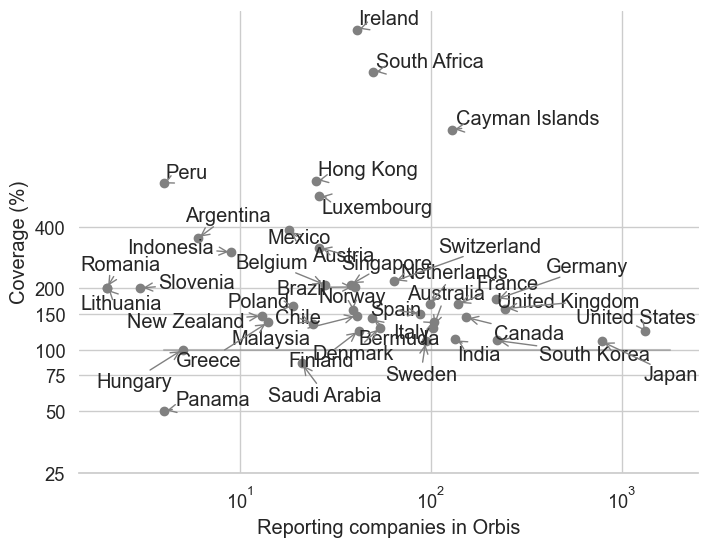

In [11]:
potential_countries = cs.loc[
    cs["Reporting companies in Orbis"] >= 3, "country"
].values  # define potential countries as all that have at least 3 GUOs in Orbis
cs = pd.concat(
    [cs.set_index("country"), total_cov], axis=1
)  # combine Orbis and CbCR data
cs.rename(columns={"Value": "Filed CbCRs"}, inplace=True)
cs["Coverage"] = np.log2(
    cs["Filed CbCRs"] / cs["Reporting companies in Orbis"]
)  # Log 2 of fraction of companies in CbCR data, compared to Orbis GUOs (WHY LOG 2???)
cs_plot = cs.dropna()  # drop NAs for plot
plt.figure(figsize=(8, 6))
plt.plot(
    cs_plot["Reporting companies in Orbis"], cs_plot["Coverage"], "o", color="grey"
)
texts = []
for c, x, y in zip(
    cs_plot.index, cs_plot["Reporting companies in Orbis"], cs_plot["Coverage"]
):
    texts.append(plt.text(x, y, tjn_tools.iso3_to_name(c)))
plt.plot([4, 1800], [0, 0], alpha=0.5, color="grey")
plt.xscale("log")
adjust_text(
    texts,
    cs_plot["Reporting companies in Orbis"].values,
    cs_plot["Coverage"].values,
    arrowprops=dict(arrowstyle="->", color="grey"),
)
bins = np.array([0.25, 0.5, 0.75, 1, 1.5, 2, 4])
coverage = np.log2(bins)
plt.yticks(coverage, np.array(100 * bins, dtype=int))
plt.xlabel("Reporting companies in Orbis")
plt.ylabel("Coverage (%)")
sns.despine(bottom=False, left=True)
expected_companies = cs["Reporting companies in Orbis"]
expected_companies = expected_companies.to_dict()
expected_companies["DNK"]

Table for CbCR coverage

In [12]:
cs_plot["Ratio"] = cs_plot["Reporting companies in Orbis"] / cs_plot["Filed CbCRs"]
x = cs_plot[["Reporting companies in Orbis", "Filed CbCRs", "Ratio"]].sort_values(
    by="Ratio", ascending=False
)
x.index = x.index.map(tjn_tools.iso3_to_name)
x["Reporting companies in Orbis"] = x["Reporting companies in Orbis"].astype(int)
x["Filed CbCRs"] = x["Filed CbCRs"].astype(int)
x["Ratio"] = x["Ratio"].round(2)
x

,Reporting companies in Orbis,Filed CbCRs,Ratio
Panama,185,2,92.81
Hungary,204,5,40.82
Lithuania,128,4,32.05
Romania,128,4,32.05
Slovenia,161,6,26.96
Saudi Arabia,323,18,17.95
Greece,289,19,15.23
New Zealand,283,19,14.91
Chile,334,32,10.44
Argentina,219,21,10.44


1.1.4 Number of available countries and reported jurisdictions - not sure we need this anymore

In [13]:
df = pd.read_csv(
    CBCR_FILE,
    usecols=[
        "COU",
        "JUR",
        "Year",
        "Partner Jurisdiction",
        "Grouping",
        "Variable",
        "Value",
    ],
)
df = df.loc[df["Grouping"] == "All Sub-Groups"]
df = df.loc[df["Year"] == YEAR_CBCR]
df = df.loc[df["Variable"].isin(fin_needed)]
df = pd.pivot_table(
    df, index=["COU", "JUR", "Partner Jurisdiction"], values="Value", columns="Variable"
).reset_index()
if "Adjusted Profit (Loss) before Income Tax" in list(df.columns):
    df.dropna(subset=["Adjusted Profit (Loss) before Income Tax"])[
        [
            "JUR",
            "Profit (Loss) before Income Tax",
            "Adjusted Profit (Loss) before Income Tax",
        ]
    ].set_index("JUR") / 1e9
df
df.dropna(subset=["Adjusted Profit (Loss) before Income Tax"])

Variable,COU,JUR,Partner Jurisdiction,Adjusted Profit (Loss) before Income Tax,Income Tax Accrued - Current Year,Income Tax Paid (on Cash Basis),Number of CbCR Sub Groups,Number of CbCRs,Number of Employees,Number of Entities,Profit (Loss) before Income Tax,Tangible Assets other than Cash and Cash Equivalents,Unrelated Party Revenues
1126,GBR,GBR,United Kingdom,1.750596e+10,1.171499e+10,1.007553e+10,387.0,387.0,3164742.0,21717.0,6.680190e+10,8.524017e+11,9.894753e+11
1875,NLD,NLD,Netherlands,2.177767e+10,4.934474e+09,4.238728e+09,165.0,165.0,582272.0,6647.0,4.613006e+10,1.246143e+11,3.088054e+11


Table 1.2 in methodology paper

In [ ]:
df = pd.read_csv(CBCR_FILE)
df = df.loc[df["Year"] == YEAR_CBCR]
df1 = df.loc[df["Grouping"] == "Sub-Groups with positive profits"]
a = (
    df1[["COU", "Partner Jurisdiction"]]
    .drop_duplicates()
    .reset_index(drop=True)["COU"]
    .value_counts()
)

df1 = df.loc[df["Grouping"] == "All Sub-Groups"]
b = (
    df1[["COU", "Partner Jurisdiction"]]
    .drop_duplicates()
    .reset_index(drop=True)["COU"]
    .value_counts()
)

pd.concat([b, a], axis=1).transpose().fillna(0).astype(int)

No clue what the following code should serve for

In [ ]:
# Make sure the cleaning in 2016  (multiplying everything by 2 in china) was mostly okay
df = pd.read_csv(
    CBCR_FILE,
    usecols=[
        "COU",
        "JUR",
        "Year",
        "Partner Jurisdiction",
        "Grouping",
        "Variable",
        "Value",
    ],
)
df = df.loc[df["Grouping"] == "Sub-Groups with positive profits"]
# df = df.loc[df["Grouping"]=="All Sub-Groups"]
df = df.loc[df["Variable"].isin(fin_needed + ["Number of CbCRs"])]
df = pd.pivot_table(
    df,
    index=["Year", "COU", "JUR", "Partner Jurisdiction"],
    values="Value",
    columns="Variable",
).reset_index()
# df.dropna(subset=["Adjusted Profit (Loss) before Income Tax"])[["JUR","Profit (Loss) before Income Tax", "Adjusted Profit (Loss) before Income Tax"]].set_index("JUR")/1E9
df.loc[(df["JUR"] == "COD")]

## 1.2 Read and clean CBCR
- Data limitations: https://www.oecd.org/tax/tax-policy/anonymised-and-aggregated-cbcr-statistics-disclaimer.pdf
- Report: https://www.oecd.org/tax/tax-policy/corporate-tax-statistics-database.htm


- Correcting for double counting of dividends:
    -  United States --> This data is cleaned in the paper by García-Bernardo, Janský & Zucman (2022)
        - US domestic: 74%
        - US foreign: 39%

    - For some countries we can correct using notes when possible:
        - Ireland: https://www.oecd.org/tax/tax-policy/ireland-cbcr-country-specific-analysis.pdf
            - 2016: No issues found
        - Italy: https://www.oecd.org/tax/tax-policy/italy-cbcr-country-specific-analysis.pdf
            - 2016: The average value of the share of dividends is instead equal to 38.2%, thus implying that dividends are concentrated in few firms.
            - 2018: The mean and the median percentage of intracompany dividends estimated to be included in the CBCR profit(loss) figure at the subgroup level is respectively 50% and 24% -> taking 50%
        - Sweden: https://www.oecd.org/tax/tax-policy/sweden-cbcr-country-specific-analysis.pdf
            - 2016: Dividends share 51.95%
            - 2018: "...under the assumption that all companies included dividends in their CbCR figures one can subtract USD 29.8 billion from USD 49.1 billion..." -> taking 60.69%
    - For Slovenia and Mexico "it does not seem to be a problem", so we don't adjust #@Javier: WHY?
    - For some countries we take the reported adjusted data
        - Netherlands: https://www.oecd.org/tax/tax-policy/united-kingdom-cbcr-country-specific-analysis.pdf
            - 2016: 5794 out of 36802 = 15.74%
            - 2017: NLD reports corrected data already in source, so we are using that
            - 2018: NLD reports corrected data already in source, so we are using that
        - United Kingdom: https://www.oecd.org/tax/tax-policy/united-kingdom-cbcr-country-specific-analysis.pdf
            - 2016: UK reported profit: The total value of dividends extracted for groups we believe had included intragroup dividends received was approximately £55 billion. (78.169865 out of 152.918884 = 51.1%)
            - 2017: UK reports corrected data already in source, so we are using that
            - 2018: UK reports corrected data already in source, so we are using that
    - For some countries the profits are negative, so we are using 0% adjustment
        - Ireland
            - 2018: has negative profits, so using 0%
        - Cayman Islands
            - 2018: has negative profits, so using 0%
        - Luxembourg
            - 2017: has negative profits, so using 0%
    - For Belgium, Singapore, Isle of Man, Bermuda, we apply 50% #@Javier: WHY?
    - For the rest, we apply the following rules:
        - Foreign income for tax havens:
            - Remove 10% (i.e. a bit more than what we find in the US for 2017 (9% = 42 double counting/454 tax havens)) #@Javier: WHY?
        - Domestic income for other countries:
            - If domestic etr << foreign etr (10 points): Correct by 35% #@Javier: WHY?
    - Groups: #@Javier: WHY? what does this do?
        - Domestic:
            - N/A
        - Foreign:
            - Remove 5% (10% from tax havens, with 50% of profits in tax havens) #@Javier: WHY?

- We correct for dividends as explained above, but not for participation results (de-mergers, takeovers and disposal typically involve tax avoidance strategies in tax havens.) 

In [ ]:
# Check out cleaning. USe all groups to get a most comparable picture
df_etrs = main_etrs(year=YEAR_CBCR, file=CBCR_FILE, g="All Sub-Groups")
df_etrs["cit"] = df_etrs.index.map(iso3_to_cit)
df_etrs

plt.figure(figsize=(12, 5))
for i, row in df_etrs.iterrows():
    if row["ETR_domestic"] > -0.2:
        if i in ["NLD", "GBR", "ITA", "SWE"]:
            color = "blue"
        else:
            color = "black"
        plt.annotate(i, (row["ETR_domestic"], row["ETR_foreign"]), color=color)
plt.plot(df_etrs["ETR_domestic"], df_etrs["ETR_foreign"], "o")


def plot_c(cs, color="tomato"):
    c, fraction = cs
    plt.plot(
        df_etrs.loc[c, "ETR_domestic"] * (1 + fraction / (1 - fraction)),
        df_etrs.loc[c, "ETR_foreign"],
        ".",
        color=color,
    )
    plt.plot(
        [
            df_etrs.loc[c, "ETR_domestic"] * (1 + fraction / (1 - fraction)),
            df_etrs.loc[c, "ETR_domestic"],
        ],
        [df_etrs.loc[c, "ETR_foreign"], df_etrs.loc[c, "ETR_foreign"]],
        lw=1,
        color=color,
    )


d_reduction = dict()
for c in df_etrs.dropna(subset=["ETR_domestic"]).index:
    # We explain the rates used here above in the markdown note.
    d = dict([("SWE", 0.6069), ("ITA", 0.5), ("USA", 0.74)]) #2018
    #    d = dict([("SWE",0.52),("ITA",0.38),("USA",0.35)]) #2017
    #    d = dict([("SWE",0.52),("ITA",0.38)]) #2016

    if c in ["BEL", "SGP", "IMN", "BMU"]:
        plot_c((c, 0.5), color="red")
        frac = 0.5
    elif c in ["SVN", "MEX"]:
        frac = 0
    elif c in d:
        plot_c((c, d[c]), color="cornflowerblue")
        frac = d[c]
    elif c in ("GBR", "NLD"):
        frac = 0  # They report their figure of adjusted profits already in the data, so we are using those
    elif c in ("IRL", "CYM"):  # 2018: IRL and CYM have negative profits (in 2017 it was LUX only)
        frac = 0
    else:
        frac = 0.35
    d_reduction[c] = frac
    plot_c((c, frac), color="gray")

plt.plot([0, 0.4], [0, 0.4], zorder=0)
plt.grid(axis="y")
sns.despine(left=True, bottom=True)
plt.xlabel("ETR (Domestic MNCs)")
plt.ylabel("ETR (Foreign MNCs)")
# plt.plot([0,0.4],[0.05,0.45])


In [ ]:
# Manually adjust countries without domestic ETRs for "sub-groups with positive profits". Use all sub-groups in this case
df = pd.read_csv(
    CBCR_FILE,
    usecols=[
        "COU",
        "JUR",
        "Year",
        "Partner Jurisdiction",
        "Grouping",
        "Variable",
        "Value",
    ],
)
df = df.loc[df["Year"] == YEAR_CBCR]
missing_c = set(
    df.loc[(df["COU"] == df["JUR"]) & (df["Grouping"] == "All Sub-Groups"), "COU"]
) - set(
    df.loc[
        (df["COU"] == df["JUR"])
        & (df["Grouping"] == "Sub-Groups with positive profits"),
        "COU",
    ]
)
df = df.loc[df["Grouping"] == "All Sub-Groups"]
df = pd.pivot_table(
    df,
    index=["Year", "COU", "JUR", "Partner Jurisdiction"],
    values="Value",
    columns="Variable",
).reset_index()
# Calculate etr
display(main_etrs(YEAR_CBCR, df.loc[(df["JUR"].isin(missing_c))]))

# Manually adjust
d_reduction["AUT"] = 0.35  # 2017 only, much lower etr domestic
d_reduction["LVA"] = 0  # 2017 only, higher for etr domestic
d_reduction["POL"] = 0.35  # 2016 and 2017much lower etr domestic

In [ ]:
# Clean data CBCR
df = pd.read_csv(
    CBCR_FILE,
    usecols=[
        "COU",
        "JUR",
        "Year",
        "Partner Jurisdiction",
        "Grouping",
        "Variable",
        "Value",
    ],
)
df = df.loc[df["Variable"].isin(fin_needed)]
# df = df.loc[df["Grouping"]=="Sub-Groups with positive profits"]
df = df.loc[df["Year"] == YEAR_CBCR]
df = pd.pivot_table(
    df,
    index=["Grouping", "COU", "JUR", "Partner Jurisdiction"],
    values="Value",
    columns="Variable",
).reset_index()
df = df.dropna(subset=["Income Tax Paid (on Cash Basis)"])


# Countries with analysis
if "Adjusted Profit (Loss) before Income Tax" in list(df.columns):
    print("Cleaning countries with corrected data: NLD and GBR")
    display(df.loc[~np.isnan(df["Adjusted Profit (Loss) before Income Tax"])])
    df.loc[
        ~np.isnan(df["Adjusted Profit (Loss) before Income Tax"]),
        "Profit (Loss) before Income Tax",
    ] = df.loc[
        ~np.isnan(df["Adjusted Profit (Loss) before Income Tax"]),
        "Adjusted Profit (Loss) before Income Tax",
    ]

print("Cleaning countries with analysis: ITA, SWE, BEL, USA")
df["Reduction"] = df["COU"].map(d_reduction).fillna(0)

filter_ = (df["COU"] == df["JUR"]) & (df["Profit (Loss) before Income Tax"] > 0)

d1 = (
    df.loc[filter_]
    .groupby(["COU", "Grouping"])["Profit (Loss) before Income Tax"]
    .sum()
    / 1e9
)
df.loc[filter_, "Profit (Loss) before Income Tax"] = df.loc[
    filter_, "Profit (Loss) before Income Tax"
] * (1 - df.loc[filter_, "Reduction"])
d2 = (
    df.loc[filter_]
    .groupby(["COU", "Grouping"])["Profit (Loss) before Income Tax"]
    .sum()
    / 1e9
)
d = pd.concat([d1, d2], axis=1).reset_index()
display(d.loc[d["Grouping"] == "All Sub-Groups"])

print("Cleaning foreign activities in tax havens")
filter_ = (
    (df["COU"] != df["JUR"])
    & (df["JUR"].isin(ofcs))
    & (df["Profit (Loss) before Income Tax"] > 0)
    & (df["COU"] == "USA")
)
print(df.loc[filter_, "Profit (Loss) before Income Tax"].sum() / 1e9)
df.loc[filter_, "Profit (Loss) before Income Tax"] = df.loc[
    filter_, "Profit (Loss) before Income Tax"] * (1 - 0.39) #2018 we take 39% of US profits away, this comes from García-Bernardo, Janský & Zucman (2022)
print(df.loc[filter_, "Profit (Loss) before Income Tax"].sum() / 1e9)

filter_ = (
    (df["COU"] != df["JUR"])
    & (df["JUR"].isin(ofcs))
    & (df["Profit (Loss) before Income Tax"] > 0)
)
print(df.loc[filter_, "Profit (Loss) before Income Tax"].sum() / 1e9)
df.loc[filter_, "Profit (Loss) before Income Tax"] = df.loc[
    filter_, "Profit (Loss) before Income Tax"] * (1 - 0.1) #2018 we take 10% away from tax havens, except the US where we take 39%. 2017 was only this line: we removed 10% everywhere
print(df.loc[filter_, "Profit (Loss) before Income Tax"].sum() / 1e9)

print("Cleaning foreign activities in groups")
filter_ = (
    (df["COU"] != df["JUR"])
    & (df["JUR"].isin(groups | {"FJT"}))
    & (df["Profit (Loss) before Income Tax"] > 0)
)
print(df.loc[filter_, "Profit (Loss) before Income Tax"].sum() / 1e9)
df.loc[filter_, "Profit (Loss) before Income Tax"] = df.loc[
    filter_, "Profit (Loss) before Income Tax"
] * (1 - 0.05)
print(df.loc[filter_, "Profit (Loss) before Income Tax"].sum() / 1e9)


df.to_excel(cbcr_output)

In [ ]:
# df = pd.read_csv(CBCR_FILE,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
df.loc[(df["COU"] == "CHN")].sort_values(by="Profit (Loss) before Income Tax").tail(10)

In [ ]:
df_etrs = main_etrs(
    year=YEAR_CBCR, file=df.loc[df["Grouping"] == "Sub-Groups with positive profits"]
)
df_etrs["cit"] = df_etrs.index.map(iso3_to_cit)
df_etrs.loc[df_etrs["ETR_foreign"] > 0.6, "ETR_foreign"] = df_etrs.loc[
    df_etrs["ETR_foreign"] > 0.6, "cit"
]
df_etrs.loc[df_etrs["ETR_total"] > 0.6, "ETR_total"] = df_etrs.loc[
    df_etrs["ETR_total"] > 0.6, "cit"
]
df_etrs.to_excel(etr_output)
df_etrs.loc["AUT"]

In [ ]:
df_etrs2 = main_etrs(
    year=YEAR_CBCR, file=CBCR_FILE, g="Sub-Groups with positive profits"
)
d = pd.concat([df_etrs, df_etrs2], axis=1)
d.columns = ["f1", "d1", "t1", "cit", "f2", "d2", "t2"]


def plot_etr_robustness(d, v2):
    plt.plot(d["f1"], d[v2], "o")
    plt.plot([0, 0.45], [0, 0.45], "--", color="gray", zorder=0)
    plt.xlabel("ETR (foreign MNCs)")
    plt.ylabel("ETR (domestic MNCs)")
    sns.despine(bottom=True, left=True)


plt.figure(figsize=(13, 4))
plt.subplot(121)
plot_etr_robustness(d, "d2")
plt.title("(A) Original data")

plt.subplot(122)
plot_etr_robustness(d, "d1")
plt.title("(B) Corrected for double counting")

In [ ]:
# Fix code for kosovo
df["COU"] = df["COU"].replace({"XKV": "XKX"})
df["JUR"] = df["JUR"].replace({"XKV": "XKX"})

In [ ]:
# df_fin.loc[df_fin["iso3_o"]=="USA"].sort_values(by="pi",ascending=False)


## 2. Create other variables to train the model

### 2.1. Financial information

In [ ]:
# Financial variables
df_fin = df.loc[
    df["Grouping"] == "All Sub-Groups",
    [
        "COU",
        "JUR",
        "Number of Employees",
        "Profit (Loss) before Income Tax",
        "Income Tax Paid (on Cash Basis)",
        "Unrelated Party Revenues",
        "Tangible Assets other than Cash and Cash Equivalents",
    ],
]
df_fin.columns = ["iso3_o", "iso3_d", "emp", "pi", "txc", "revt", "t_at"]
df_fin["iso3_d"] = df_fin["iso3_d"].replace("ANT", "CUW")

In [ ]:
## Countries to include
countries_include = set(
    [
        _
        for _ in df_fin["iso3_d"].unique()
        if not isinstance(tjn_tools.get_iso3(_), float)
    ]
) - {
    "IOT",
    "BVT",
}  # - {"BVT","GUM","ASM","VIR"} #tiny ocuntry with almost no profits, not in the distance dataset

### 2.2 Import and generate additional relevant variables

2.2.1 Import country-level variables and construct additional variables

In [ ]:
## Import geographic information and FSI & CTHI
region = pd.read_csv(
    UNILATERAL_CROSS,
    usecols=[
        "iso3",
        "region_tjn",
        "region",
        "ukt",
        "oecd",
        "oecd_oct",
        "eu28",
        "g20",
        "fsi_2022_rank",
        "fsi_2022_score",
        "cthi_2021_rank",
        "cthi_2021_share",
        "cthi_2021_score",
    ],
)

## Import other variables needed
usecols = [
    "iso3",
    "year",
    "gdp",
    "population",
    "physicians_per_1000",
    "nurses_per_1000",
    "greenfieldfdi_inward",
    "greenfieldfdi_outward",
    "resource_revenue",
    "resource_taxes",
    "total_taxes_revenue",
    "cit_revenue",
    "health_exp_gdp",
    "govt_exp_educ_gdp",
    "fdi_inflows_wdi",
    "external_debt_stocks",
    "ip_payments",
    "ip_receipts",
    "who_gvt_health_expenditure",
    "month_wage",
    "new_businesses_registered",
    "imports",
    "exports",
    "gdp_pc",
    "gdp_deflator",
    "govt_exp_gdp",
]
other_info = pd.read_csv(UNILATERAL_PANEL, usecols=usecols)

# Fill GDP, population, nurses, and physicians with info from previous/earlier years
for i in ["gdp", "population", "physicians_per_1000", "nurses_per_1000"]:
    other_info[i] = other_info.groupby("iso3")[i].bfill(limit=3)
    other_info[i] = other_info.groupby("iso3")[i].ffill(limit=3)
    
# Only keep average of the last 5 years
# DOES THIS MAKE SENSE??? Mirek: I don't think we need to do this, and it was not working properly anyway (we were taking average of 2012-2022), not just the last 5 years prior to 2018.
#other_info = (other_info.loc[other_info["year"] > last_year_mean].groupby("iso3").mean().reset_index())
#Mirek: instead, I think we need to just take the CBCR_YEAR here:
other_info = (other_info.loc[other_info["year"] == YEAR_CBCR])

# Merge geographic and other information
other_info = pd.merge(other_info, region, how="outer")

# Calculate total number of physicians and nurses
other_info["physicians"] = (
    other_info["physicians_per_1000"] * other_info["population"] / 1000
)
other_info["nurses"] = other_info["nurses_per_1000"] * other_info["population"] / 1000

# Convert expenditures (which are measured as % of GDP) to USD
for i in [
    "who_gvt_health_expenditure",
    "resource_revenue",
    "resource_taxes",
    "total_taxes_revenue",
    "cit_revenue",
    "health_exp_gdp",
    "govt_exp_educ_gdp",
    "govt_exp_gdp",
]:
    other_info[i] = other_info[i] * other_info["gdp"]

# Calculate resource revenue as fraction of GDP
other_info["resource_revenue_gdp"] = other_info["resource_revenue"] / other_info["gdp"]

# Covert variables given in % to fractions
other_info["govt_exp_educ_gdp"] /= 100
other_info["health_exp_gdp"] /= 100

# add corporate income tax rate to dataset
other_info["cit"] = other_info["iso3"].map(iso3_to_cit)

2.2.2 Clean wage variable
- Javier has removed the wage variable when the wage was too high/too low in comparison to GDP. 
- I am not sure if we want to follow this approach as I think that the  "mismatch" might be linked to profit shifting variables or just a sign that profit is shifted. For instance, Cyprus wages are lower than "expected", but this could be the case because Cyprus' GDP is inflated by activities related to profit shifting. If we systematically remove observations linked to high profit shifting (in or out), this might bias our results without need.

In [ ]:
# Identify implausible values
remove = []  # Create list of observations to be removed due to implausible values
for i, x, y in zip(
    other_info["iso3"],
    other_info["gdp"] / other_info["population"],
    other_info["month_wage"],
):  # Detect implausible values for monthly wages
    if (np.log(x / 12 / y) > np.log2(1.5)) or (
        np.log(x / 12 / y) < -2
    ):  # rule of thumb which values are plausible (and which not)
        print(i, x / 12, y, np.abs(np.log(x / 12 / y)))
        plt.annotate(i, (x, y))
        remove.append(i)
plt.plot(
    other_info["gdp"] / other_info["population"], other_info["month_wage"], "."
)  # Plot relationship between GDP/capita and wages
plt.xscale("log")
plt.yscale("log")
plt.xlabel("GDP per capita")
plt.ylabel("Wage")
# remove implausible values and substitue missing values
other_info.loc[
    other_info["iso3"].isin(remove), "month_wage"
] = (
    np.nan
)  # Delete observations where wage variable deviates too much from what we'd expect from GDP per capita
mod = smf.ols(
    formula="np.log(month_wage) ~ np.log(gdp) + np.log(population)", data=other_info
)  # Predict wage based on GDP and population to substitute missing or implausible values
res = mod.fit()
print(res.summary())
other_info["pred_month_wage"] = np.exp(
    res.predict(other_info)
)  # Include predicted wages in dataset
other_info.loc[np.isnan(other_info["month_wage"]), "month_wage"] = other_info.loc[
    np.isnan(other_info["month_wage"]), "pred_month_wage"
]  # substitute wages with predicted wages if wages are missing
del other_info["pred_month_wage"]  # delete predicted wages
other_info.loc[
    other_info["iso3"] == "USA", "month_wage"
] = 4400  # Fix values for US according to https://www.bls.gov/news.release/pdf/wkyeng.pdf
other_info.loc[
    other_info["iso3"] == "AUS", "month_wage"
] = 4911  # Fix values for Australia according to https://www.abs.gov.au/statistics/labour/earnings-and-work-hours/average-weekly-earnings-australia/latest-release

2.2.3 Check and export dataset and parts of it

In [ ]:
# Check dataset
duplicates = other_info[other_info.duplicated()]
print(duplicates)
other_info.sample(10)
# Export dataset
other_info.to_csv(info_expenditures_output, sep="\t", index=None)
# Export country's GDP to dictionary
iso3_to_gdp = other_info.set_index("iso3")["gdp"].dropna().to_dict()
pickle.dump(iso3_to_gdp, open(iso3_to_gdp_output, "wb+"))

In [ ]:
a = pd.read_csv(UNILATERAL_PANEL, skiprows=1, sep="\t", nrows=1).columns
[_ for _ in a if "govt_ex" in _.lower()]

In [ ]:
# Other info
df_region = other_info.drop(columns=["year"])
df_region = df_region.rename(columns={"iso3": "iso3_d"})
df_region = df_region.drop_duplicates(subset=["iso3_d"]).dropna(subset=["iso3_d"])
iso3_to_region = df_region.set_index("iso3_d")["region_tjn"]

In [ ]:
iso3_to_wages = other_info.set_index("iso3")["month_wage"].dropna().to_dict()
pickle.dump(iso3_to_wages, open(iso3_to_wages_output, "wb+"))

In [ ]:
other_info.set_index("iso3")["month_wage"]


## 2.3 Gravity dataset

In [ ]:
def add_eq(df_dist, list_c, eq):
    """copies the data of another country"""
    for c in list_c:
        x = df_dist.loc[df_dist["iso3_o"] == eq]
        x["iso3_o"] = c
        df_dist = pd.concat([df_dist, x])
        x = df_dist.loc[df_dist["iso3_d"] == eq]
        x["iso3_d"] = c
        df_dist = pd.concat([df_dist, x])
    return df_dist

In [ ]:
# Read gravity variables
df_dist = pd.read_stata(GRAV_FILE)  # import gravity dataset
variables_to_import = list(
    filter(lambda x: x.startswith("dist"), df_dist.columns)
)  # only keep dist variables
variables_to_import.extend(
    ["iso3_o", "iso3_d", "year"]
)  # ... and iso3_o, iso3_d and year
df_dist = df_dist.loc[:, variables_to_import]
df_dist = (
    df_dist.loc[df_dist["year"] > last_year_mean]
    .groupby(["iso3_o", "iso3_d"])
    .mean()
    .reset_index()
)

df_dist["iso3_o"] = df_dist["iso3_o"].str.replace("ROM", "ROU")
df_dist["iso3_d"] = df_dist["iso3_d"].str.replace("ROM", "ROU")
df_dist["iso3_o"] = df_dist["iso3_o"].str.replace("TLS", "TMP")
df_dist["iso3_d"] = df_dist["iso3_d"].str.replace("TLS", "TMP")
# df_dist["iso3_o"] = df_dist["iso3_o"].str.replace("ANT","CUW")
# df_dist["iso3_d"] = df_dist["iso3_d"].str.replace("ANT","CUW")
df_dist = df_dist.loc[(df_dist["iso3_o"] != "ANT") & (df_dist["iso3_d"] != "ANT")]

df_dist = add_eq(df_dist, ["JEY", "IMN", "GGY"], "GBR")
# df_dist = add_eq(df_dist,["SRB","MNE"],"ALB")
# df_dist = add_eq(df_dist,["MCO"],"AND")
# df_dist = add_eq(df_dist,["SSD"],"SDN")
# df_dist = add_eq(df_dist,["COD"],"COG")
df_dist = add_eq(df_dist, ["TLS"], "COG")

In [ ]:
df_dist["iso3_d"].value_counts().head(5)  # make sure there are no duplicates

In [ ]:
set(df_fin["iso3_d"]) - set(df_dist["iso3_o"])


In [ ]:
for i in set(df_fin["iso3_d"]) - set(df_dist["iso3_o"]):
    try:
        iso3_to_name(i)
    except:
        print(i)


## 2.4 Variables from Linkedin

In [ ]:
# Linkedin variables
df_link = pd.read_csv(
    LINK_FILE, sep="\t", index_col=0, na_values=[""], keep_default_na=False
)
df_link["iso3_d"] = df_link["index"].map(tjn_tools.get_iso3)
df_link = df_link.drop(columns=["index", "country", "ln_pi"])
df_link = df_link.drop_duplicates(subset=["iso3_d"])

## 2.5 Bilateral info

In [ ]:
df_bil = pd.read_csv(BILATERAL_PANEL)
df_bil = df_bil.groupby(["r_iso3", "p_iso3"]).mean().reset_index()
df_bil = df_bil.loc[
    :,
    [
        "r_iso3",
        "p_iso3",
        "export",
        "import",
        "dclaims",
        "dliabilities",
        "porti_inward",
        "porti_outward",
        "fdi_inward",
        "fdi_outward",
    ],
]
for v in [
    "export",
    "import",
    "dclaims",
    "dliabilities",
    "porti_inward",
    "porti_outward",
    "fdi_inward",
    "fdi_outward",
]:
    df_bil["ln_" + v] = np.log(df_bil[v] + 1)
    del df_bil[v]
df_bil = df_bil.rename(columns={"r_iso3": "iso3_o", "p_iso3": "iso3_d"})
df_bil

## 2.5 Combine datasets into a bilateral dataset

In [ ]:
iso3_to_etr = df_etrs["ETR_total"].to_dict()


In [ ]:
## Dataset to impute (financials and weird stuff) (destination files)
# Keep the non-bilateral columns (note the drop_duplicates)
x = df_dist.loc[
    :,
    [
        _
        for _ in df_dist.columns
        if (_[-2:] == "_d")
        and (
            _
            not in [
                "heg_d",
                "gsp_d_d",
                "gsp_o_d",
                "eu_d",
                "tradeflow_comtrade_d",
                "tradeflow_imf_d",
            ]
        )
    ],
].drop_duplicates()
print(x.shape)  # should be around 257 countries

df_destination = pd.merge(x, df_region, how="outer")
df_destination = pd.merge(
    df_destination,
    df_link.drop(columns=["cit", "ln_gdp"]),
    how="left",
    on=["iso3_d"],
    suffixes=["", "_d"],
)
df_destination["n_companies_orb"] = (
    df_destination["iso3_d"].map(expected_companies).fillna(0)
)

# Add efective tax rate
df_destination["etr_real_d"] = df_destination["iso3_d"].map(iso3_to_etr)
df_destination["ln_etr_real_d"] = np.log(0.001 + df_destination["etr_real_d"])
df_destination = df_destination.dropna(subset=["gdp"])

remove_cols_dest = df_destination.columns

# Take the logarithm for many variables
columns = np.array(df_destination.columns)[df_destination.dtypes != object]
for var in columns:
    if (
        (var == "english")
        or (var == "etr")
        or ("ln" in var)
        or ("comrelig" in var)
        or ("comleg" in var)
    ):  # or ("cit" == var): #TO REVIEW if last clause if correct - Introduced to avoid error running the notebook #TODO
        continue
    if len(df_destination.loc[:, var].unique()) < 5:
        continue
    m = np.min(df_destination.loc[:, var].dropna())
    if m > 0:
        m = 0
    #     print(var,m,np.mean(df_destination.loc[:,var]-m)/(np.median(df_destination.loc[:,var].dropna()-m)))
    if (
        ("GDP" in var)
        or (var == "distw")
        or (
            (
                np.mean(df_destination.loc[:, var] - m)
                > 2.0 * np.median(df_destination.loc[:, var].dropna() - m)
            )
        )
    ):  # or (var in ["Total FSI","cthi"]):
        print(
            var,
            m,
            np.mean(df_destination.loc[:, var] - m)
            / (np.median(df_destination.loc[:, var].dropna() - m)),
        )
        df_destination["ln_" + var] = np.log(1 + df_destination.loc[:, var] - m)
        del df_destination[var]

In [ ]:
df_destination = df_destination.loc[(df_destination["iso3_d"] != "WLD")]

columns = np.array(df_destination.columns)[df_destination.dtypes != object]
# df_destination = impute(df_destination,columns)


df_destination.columns = [
    _ + "_d" if _[-2:] != "_d" else _ for _ in df_destination.columns
]

for var in [
    "ln_resource_revenue_d",
    "ln_resource_revenue_gdp_d",
    "ln_total_taxes_revenue_d",
    "ln_cit_revenue_d",
]:
    df_destination.loc[df_destination[var] < 0, var] = 0


df_destination2 = df_destination.copy()
df_destination2.columns = [
    _[:-1] + "o" if _[-2:] == "_d" else _ for _ in df_destination.columns
]

# #Add dummies
# df_destination = pd.concat([df_destination,pd.get_dummies(df_destination["iso3_d"])],axis=1)

print(df_destination.shape)

countries_include - set(df_destination["iso3_d"])

In [ ]:
# Create a full dataset
pairs = list(product(countries_include, repeat=2))
pairs = pd.DataFrame(pairs, columns=["iso3_o", "iso3_d"])

pairs = pd.merge(pairs, df_fin, how="left", validate="1:1")
pairs = pd.merge(pairs, df_destination, how="left", on=["iso3_d"], validate="m:1")
pairs = pd.merge(
    pairs,
    df_destination2,
    how="left",
    suffixes=["_d", "_o"],
    on=["iso3_o"],
    validate="m:1",
)

df_dist2 = df_dist.loc[
    :,
    ["iso3_o", "iso3_d"]
    + [
        _
        for _ in df_dist
        if (_ not in df_destination.columns)
        and (_ not in df_destination2.columns)
        and ("ln" + _ not in df_destination.columns)
        and ("ln" + _ not in df_destination2.columns)
        and (_ not in remove_cols_dest)
    ],
]
pairs = pd.merge(pairs, df_dist2, how="left", on=["iso3_o", "iso3_d"], validate="1:1")
pairs = pd.merge(pairs, df_bil, how="left", on=["iso3_o", "iso3_d"], validate="1:1")

# pairs = pairs.drop(columns=["conflict","indepdate","sever","sib_conflict","pta_bb","fta_bb","fta_hmr"])
# pairs = pairs.drop(columns=["sib_conflict"])


print(pairs.dropna(subset=["pi"]).shape)

In [ ]:
# Lines commented to hot fix issue - Originally not commented
pairs["ln_etr_real_o"] = np.log(0.01 + pairs["etr_real_o"])
pairs["ln_etr_real_d"] = np.log(0.01 + pairs["etr_real_d"])

In [ ]:
# Originally not existing
# pairs["etr_real_o"] = np.exp(pairs["ln_etr_real_o"])-0.01


In [ ]:
pairs["ln_cit_o"] = np.log(0.01 + pairs["cit_o"])
pairs["ln_cit_d"] = np.log(0.01 + pairs["cit_d"])

In [ ]:
set(
    [
        "gdp_o",
        "pop_o",
        "gdpcap_o",
        "entry_cost_o",
        "area_o",
        "eu_o",
        "eu_d",
        "year",
        "region_d",
        "region_o",
    ]
) - set(pairs.columns)

Maybe de-comment line below, depending on if we need these variables (mostly part of gravity file)

In [ ]:
pairs = pairs.drop(columns=["year", "region_d", "region_o"])
# pairs = pairs.drop(columns=["gdp_o","pop_o","gdpcap_o","entry_cost_o","eu_o","eu_d","year","region_d","region_o"])

In [ ]:
for i in pairs.columns:
    if len(pairs) - pairs[i].count() > 0:
        print(i, len(pairs) - pairs[i].count())

In [ ]:
# #fill missing (very few values coming from the distancefile only)
# columns = np.array(pairs.columns)[pairs.dtypes!=object]
# columns = [_ for _ in columns if _ not in df_fin.columns]

# # pairs = impute(pairs,columns)


In [ ]:
for var in ["emp", "revt", "pi", "t_at", "distw"]:
    pairs["ln_" + var] = np.log(1 + pairs.loc[:, var] - m)
    del pairs[var]

In [ ]:
pairs.to_csv(df_pairs_output, sep="\t", index=None)
df_fin.to_csv(df_fin_output, sep="\t", index=None)

In [ ]:
df_fin.head()


In [ ]:
pairs.head()


In [ ]:
df_region_notna = df_region.dropna(subset=["iso3_d", "region_tjn"])
OAF = AFRIC = set(
    df_region_notna.loc[df_region_notna["region_tjn"] == "Africa", "iso3_d"].dropna()
)
OAS = ASIAT = set(
    df_region_notna.loc[df_region_notna["region_tjn"] == "Asia", "iso3_d"].dropna()
)
OTE = EUROP = set(
    df_region_notna.loc[df_region_notna["region_tjn"] == "Europe", "iso3_d"].dropna()
)
OAM = LAC_sca = set(
    df_region_notna.loc[
        df_region_notna["region_tjn"].str.contains("America"), "iso3_d"
    ].dropna()
)
GRPS = set(df_region_notna["iso3_d"].dropna())
LAC = set(
    df_region_notna.loc[
        df_region_notna["region_tjn"] == "Latin America and the Caribbean", "iso3_d"
    ].dropna()
)

d_groups2countries = {
    "OAF": OAF,
    "AFRIC": AFRIC,
    "OAS": OAS,
    "ASIAT": ASIAT,
    "OTE": OTE,
    "EUROP": EUROP,
    "OAM": OAM,
    "LAC_sca": LAC_sca,
    "GRPS": GRPS,
    "LAC": LAC,
}

pickle.dump(d_groups2countries, open(d_groups2countries_output, "wb+"))